In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("C:/AEGIS/roadmap/Traditional_ML/day_02/data/churn.csv")
df

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
0,16,128,415,2845,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,2301,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,1616,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,2510,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,155,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,11,50,408,2000,0,1,40,235.7,127,40.07,223.0,126,18.96,297.5,116,13.39,9.9,5,2.67,2,0
4996,49,152,415,394,0,0,0,184.2,90,31.31,256.8,73,21.83,213.6,113,9.61,14.7,2,3.97,3,1
4997,7,61,415,313,0,0,0,140.6,89,23.90,172.8,128,14.69,212.4,97,9.56,13.6,4,3.67,1,0
4998,7,109,510,3471,0,0,0,188.8,67,32.10,171.7,92,14.59,224.4,89,10.10,8.5,6,2.30,0,0


In [3]:
df.shape

(5000, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          5000 non-null   int64  
 1   account_length                 5000 non-null   int64  
 2   area_code                      5000 non-null   int64  
 3   phone_number                   5000 non-null   int64  
 4   international_plan             5000 non-null   int64  
 5   voice_mail_plan                5000 non-null   int64  
 6   number_vmail_messages          5000 non-null   int64  
 7   total_day_minutes              5000 non-null   float64
 8   total_day_calls                5000 non-null   int64  
 9   total_day_charge               5000 non-null   float64
 10  total_eve_minutes              5000 non-null   float64
 11  total_eve_calls                5000 non-null   int64  
 12  total_eve_charge               5000 non-null   float64
 13 

In [5]:
df.describe()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
count,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,25.99840,100.25860,436.911400,2499.500000,0.094600,0.264600,7.755200,180.288900,100.029400,30.649668,200.636560,100.191000,17.054322,200.391620,99.919200,9.017732,10.261780,4.435200,2.771196,1.570400,0.141400
std,14.80348,39.69456,42.209182,1443.520003,0.292691,0.441164,13.546393,53.894699,19.831197,9.162069,50.551309,19.826496,4.296843,50.527789,19.958686,2.273763,2.761396,2.456788,0.745514,1.306363,0.348469
min,0.00000,1.00000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.00000,73.00000,408.000000,1249.750000,0.000000,0.000000,0.000000,143.700000,87.000000,24.430000,166.375000,87.000000,14.140000,166.900000,87.000000,7.510000,8.500000,3.000000,2.300000,1.000000,0.000000
50%,26.00000,100.00000,415.000000,2499.500000,0.000000,0.000000,0.000000,180.100000,100.000000,30.620000,201.000000,100.000000,17.090000,200.400000,100.000000,9.020000,10.300000,4.000000,2.780000,1.000000,0.000000
75%,39.00000,127.00000,415.000000,3749.250000,0.000000,1.000000,17.000000,216.200000,113.000000,36.750000,234.100000,114.000000,19.900000,234.700000,113.000000,10.560000,12.000000,6.000000,3.240000,2.000000,0.000000
max,50.00000,243.00000,510.000000,4999.000000,1.000000,1.000000,52.000000,351.500000,165.000000,59.760000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000


<Axes: xlabel='class'>

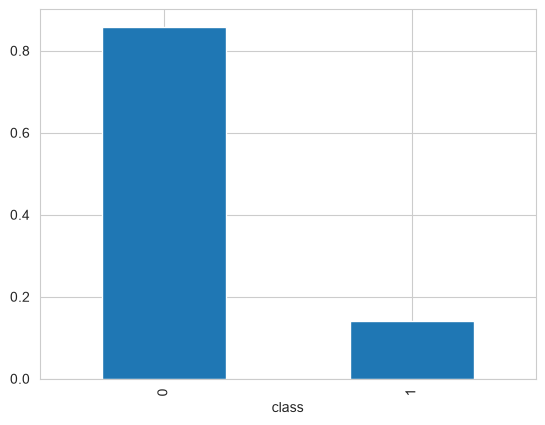

In [6]:
df['class'].value_counts(normalize=True).plot(kind = 'bar')

In [7]:
df.isna().sum()

state                            0
account_length                   0
area_code                        0
phone_number                     0
international_plan               0
voice_mail_plan                  0
number_vmail_messages            0
total_day_minutes                0
total_day_calls                  0
total_day_charge                 0
total_eve_minutes                0
total_eve_calls                  0
total_eve_charge                 0
total_night_minutes              0
total_night_calls                0
total_night_charge               0
total_intl_minutes               0
total_intl_calls                 0
total_intl_charge                0
number_customer_service_calls    0
class                            0
dtype: int64

> ## No missing data

In [8]:
df.duplicated().sum()

np.int64(0)

> ## No Duplicated Data

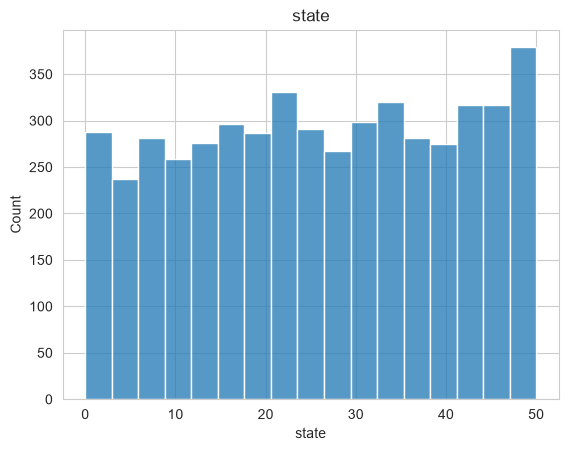

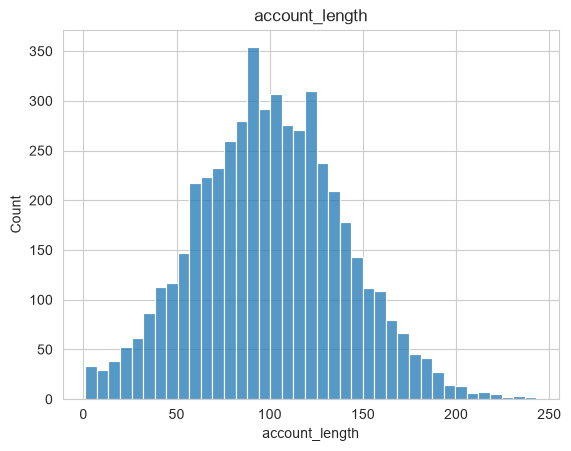

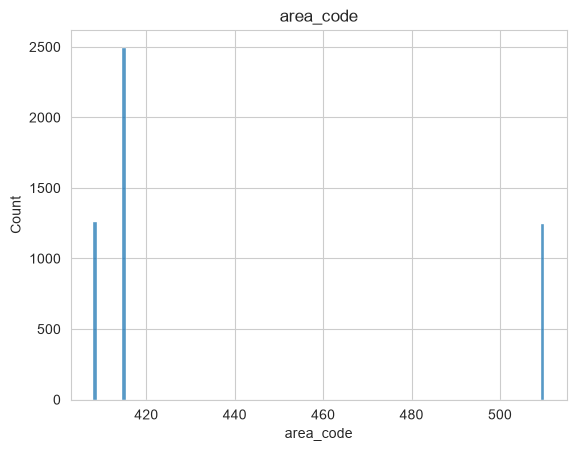

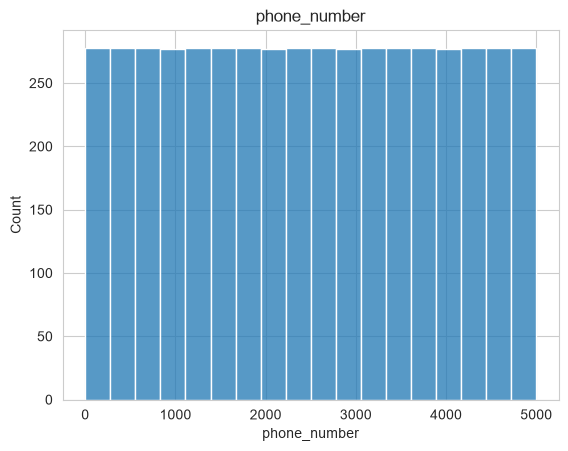

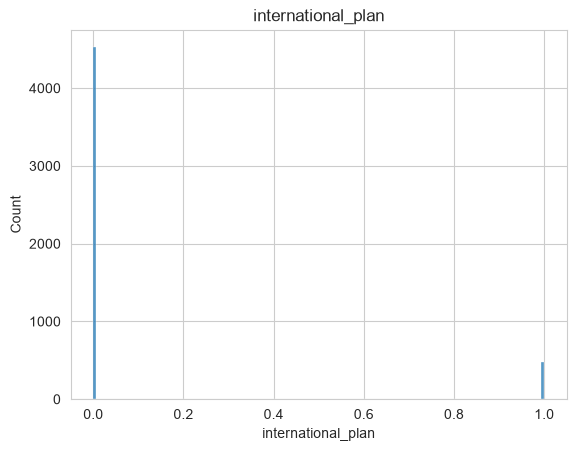

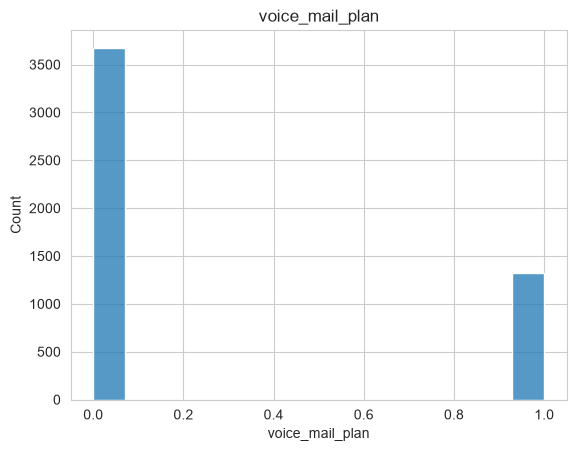

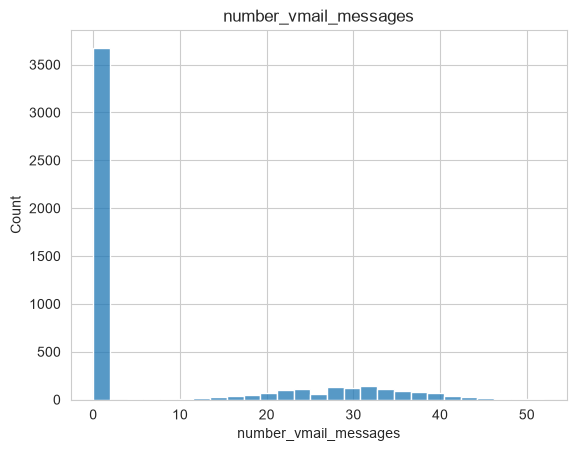

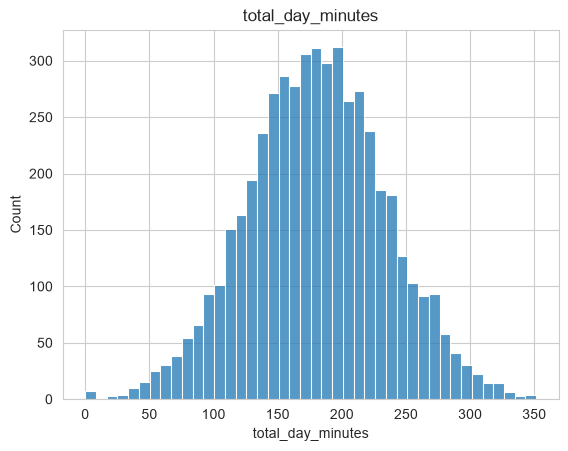

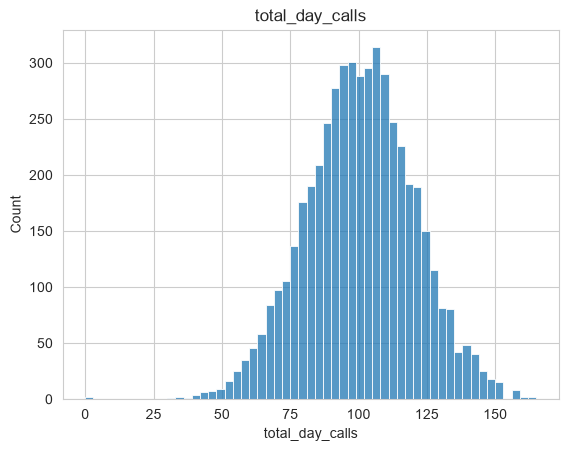

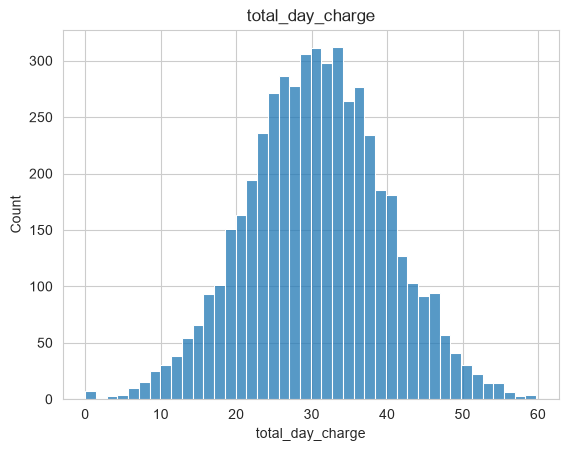

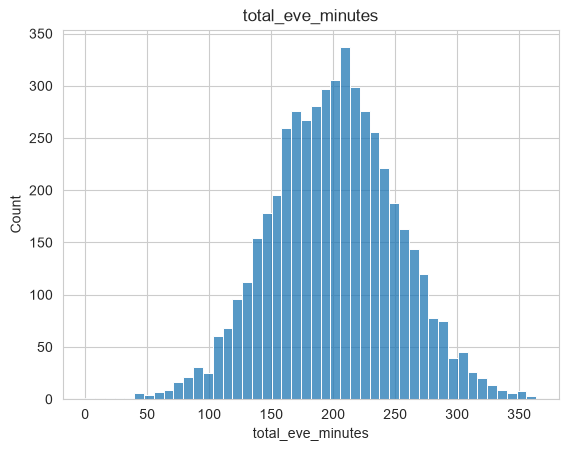

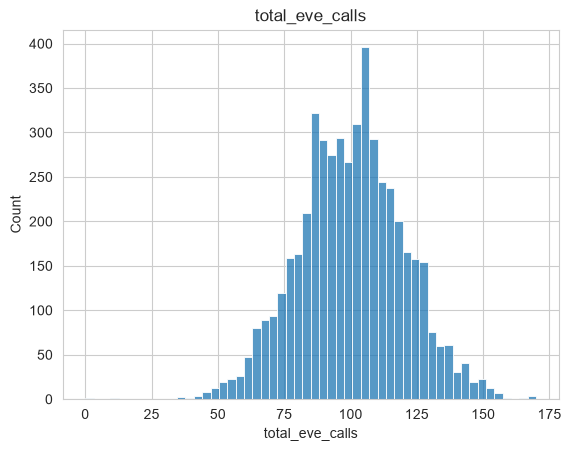

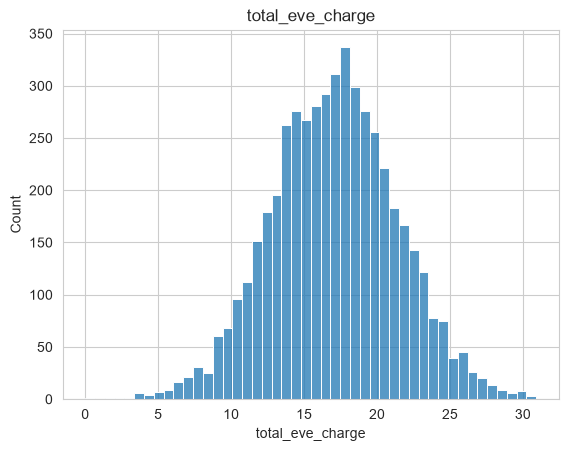

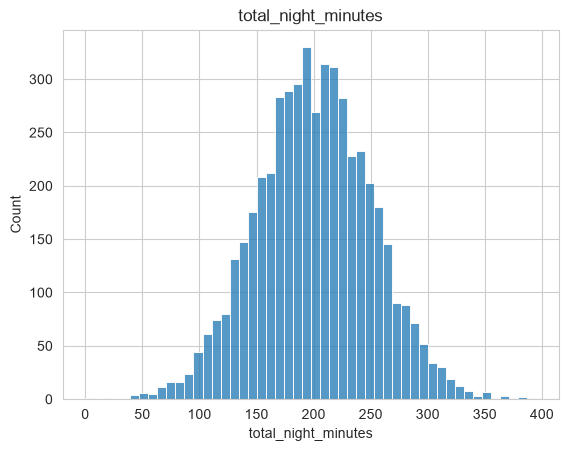

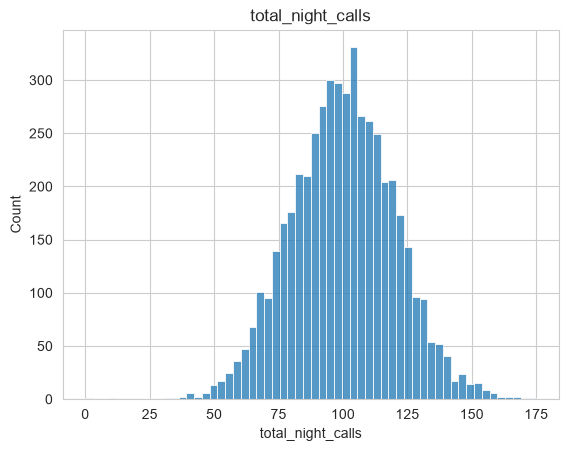

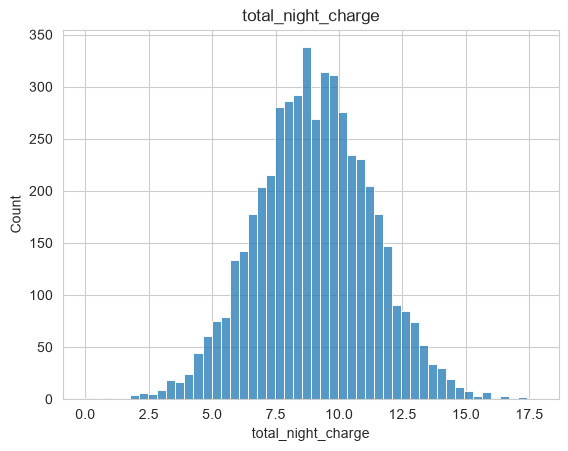

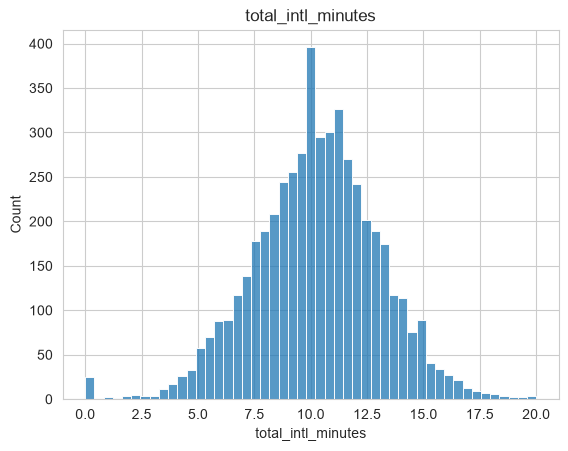

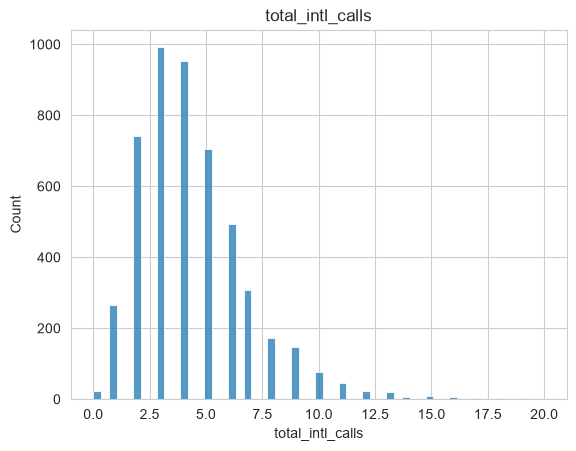

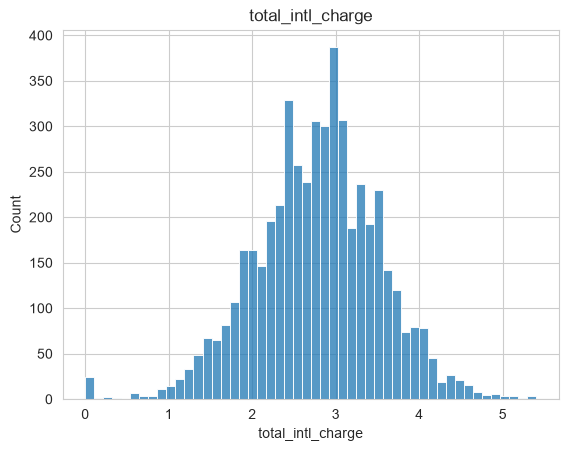

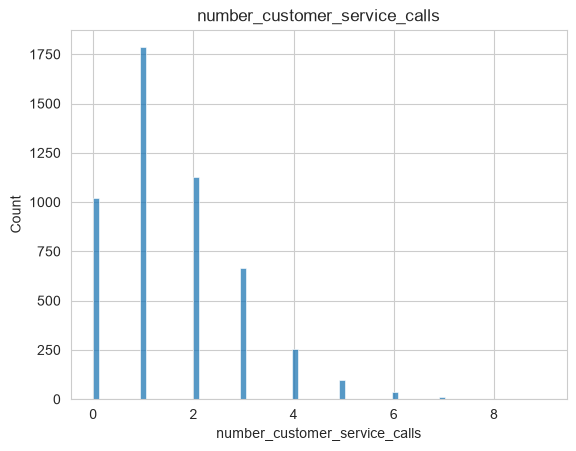

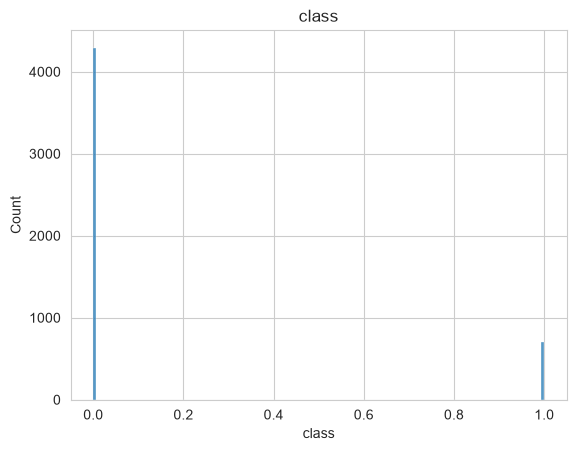

In [9]:
for col in df.columns:
    sns.histplot(df[col])
    plt.title(col)
    plt.show()

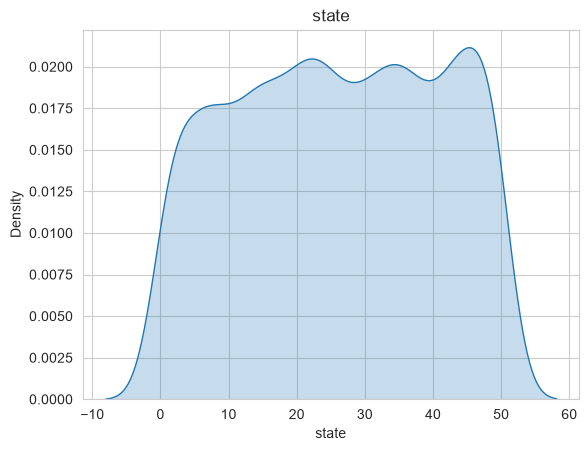

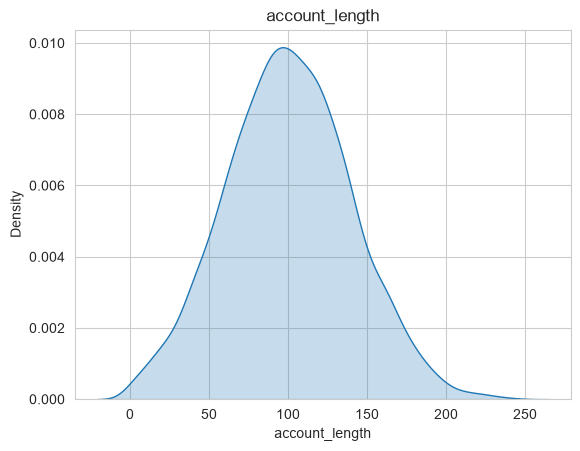

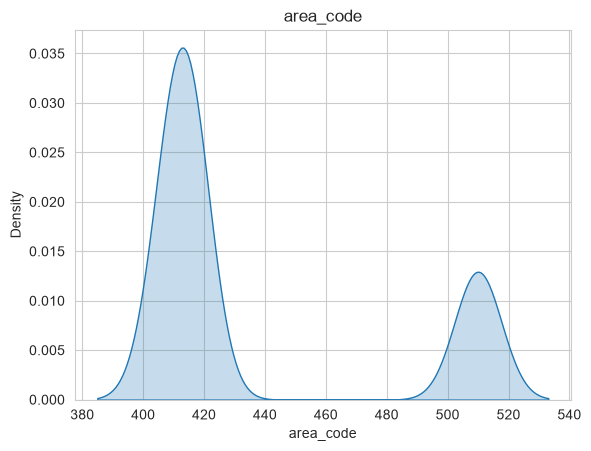

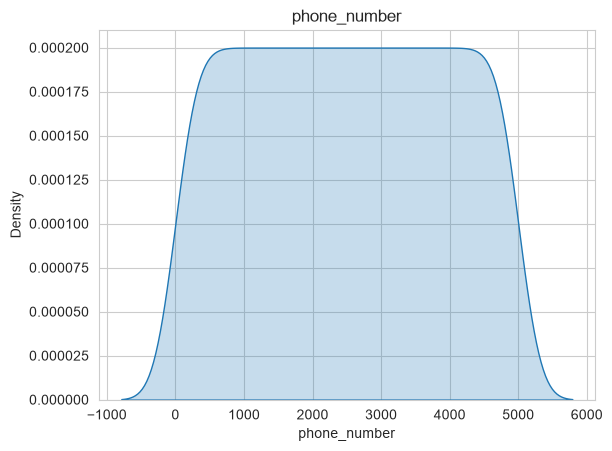

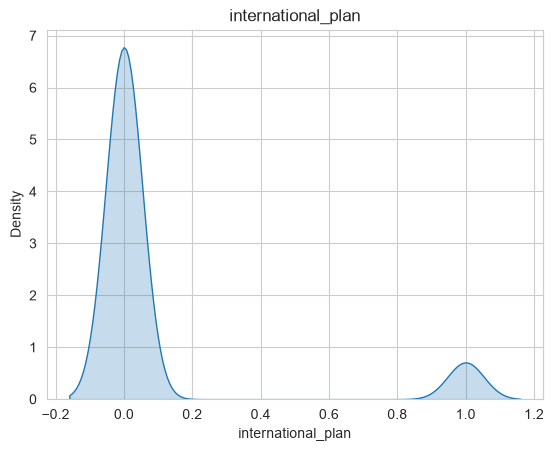

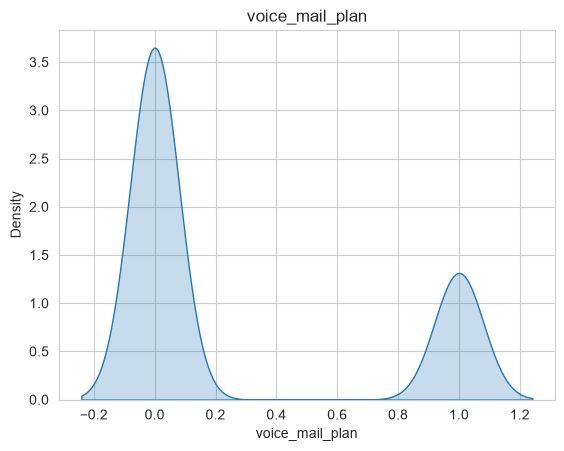

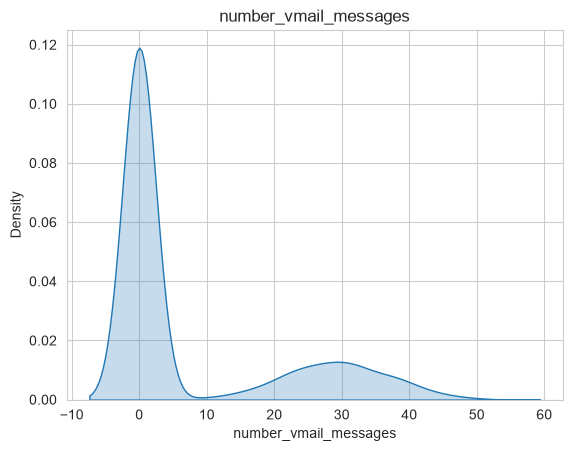

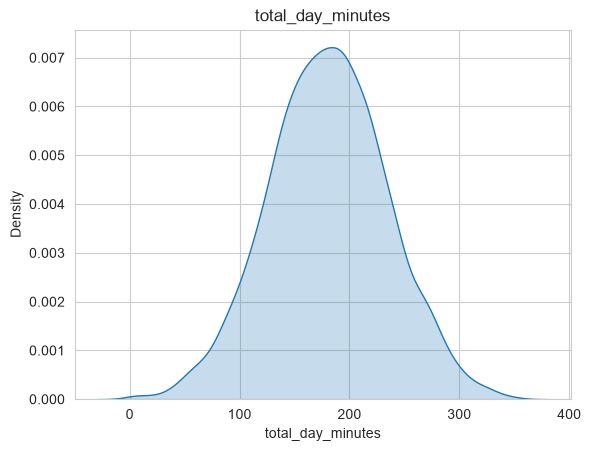

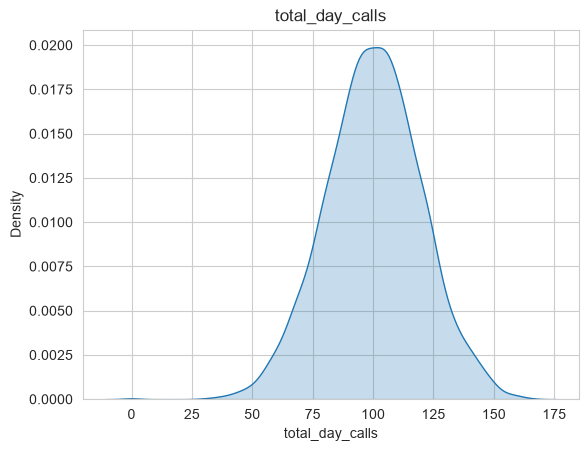

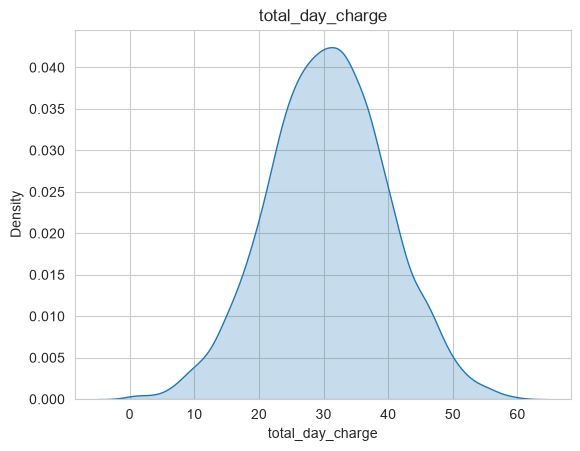

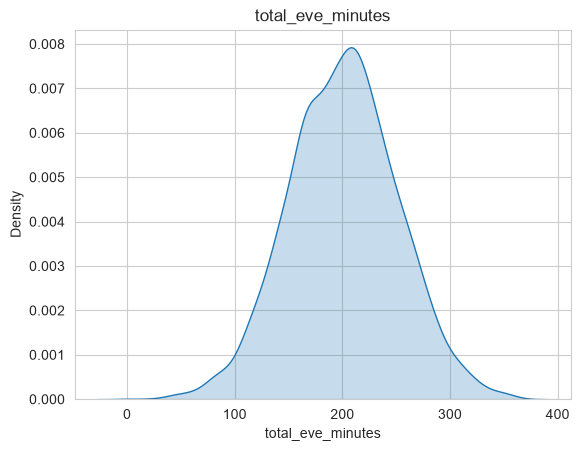

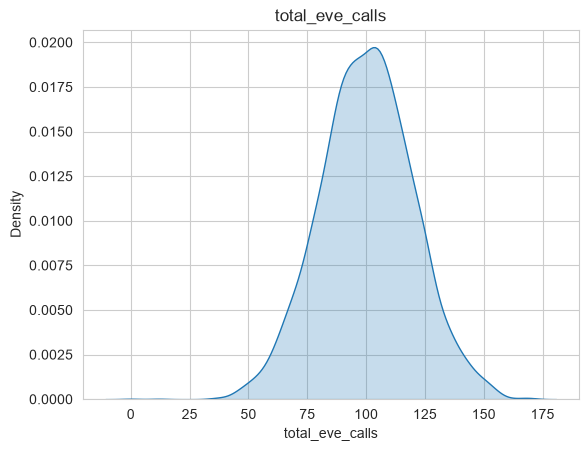

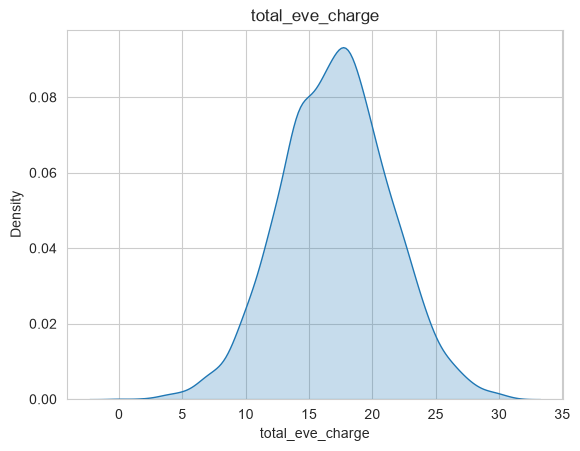

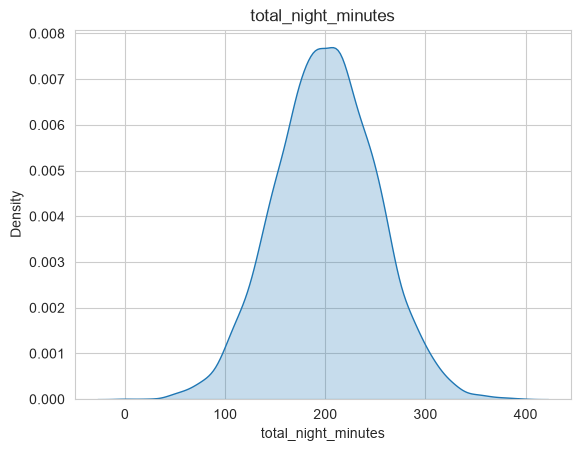

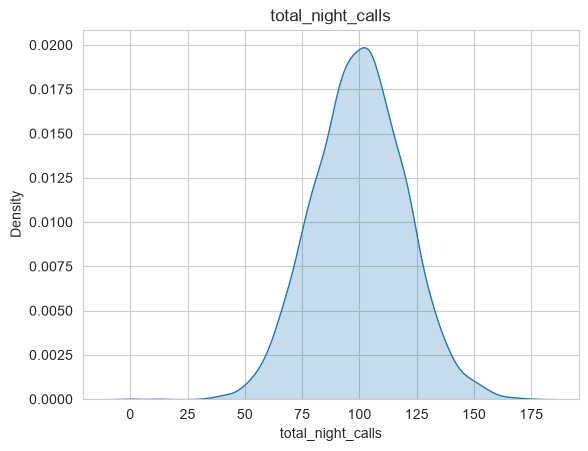

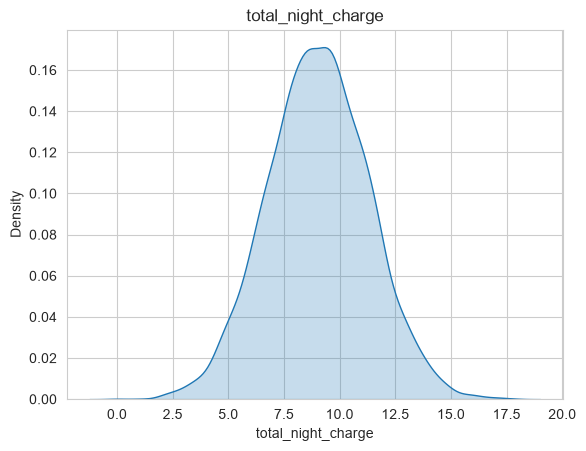

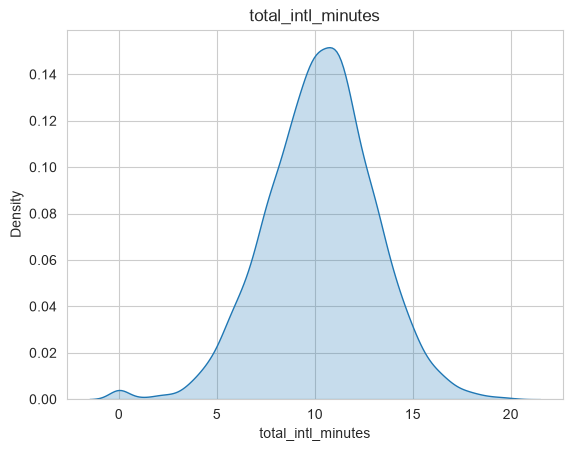

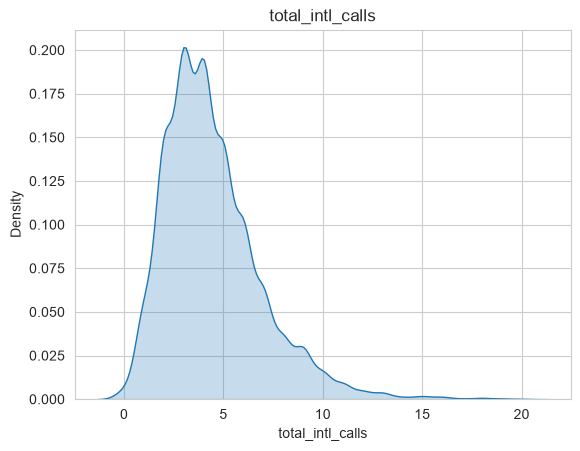

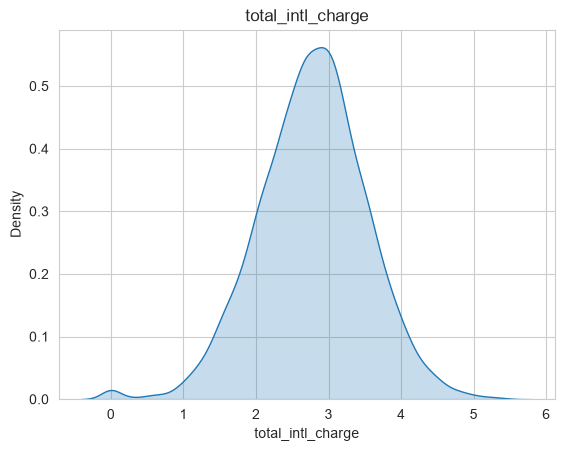

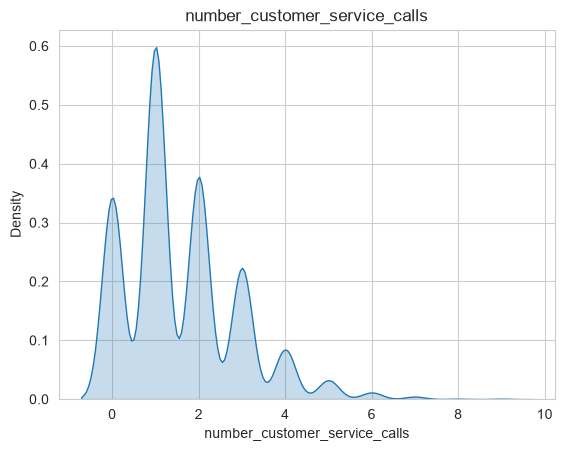

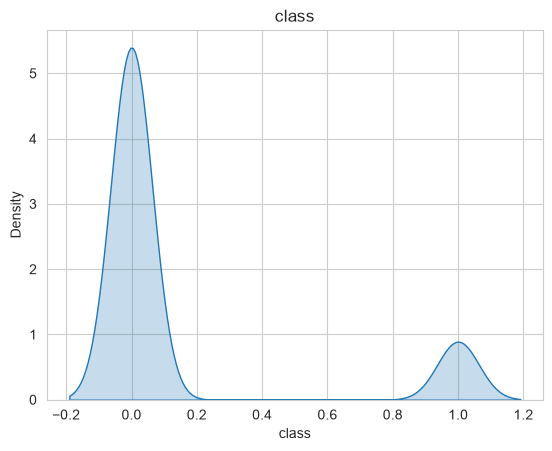

In [10]:
for col in df.columns:
    sns.kdeplot(df[col], fill=True)
    plt.title(col)
    plt.show()

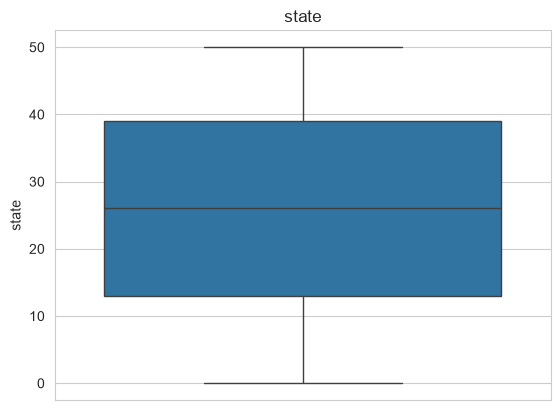

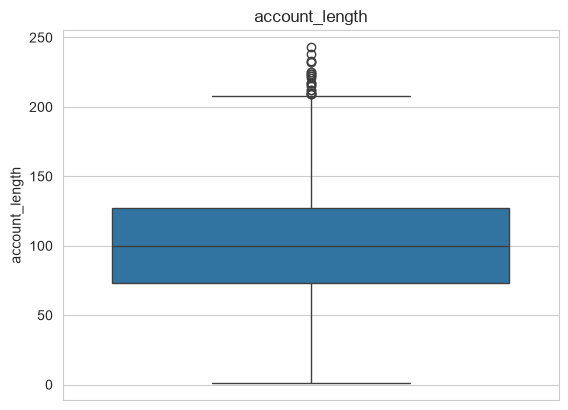

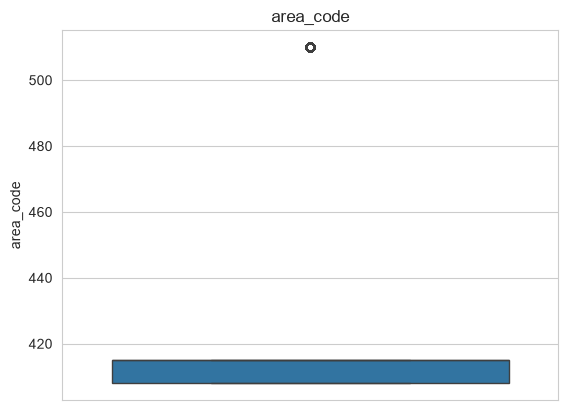

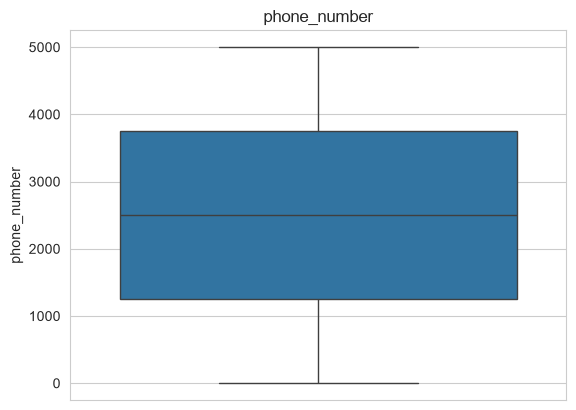

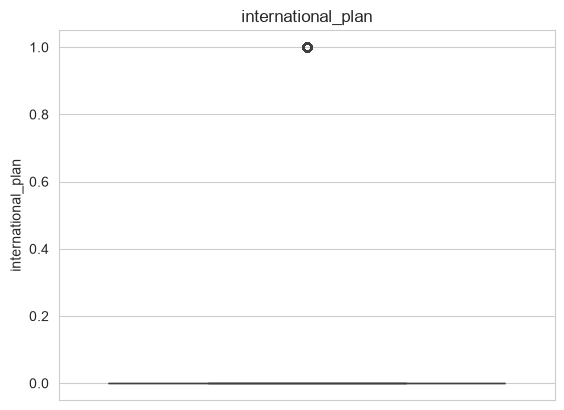

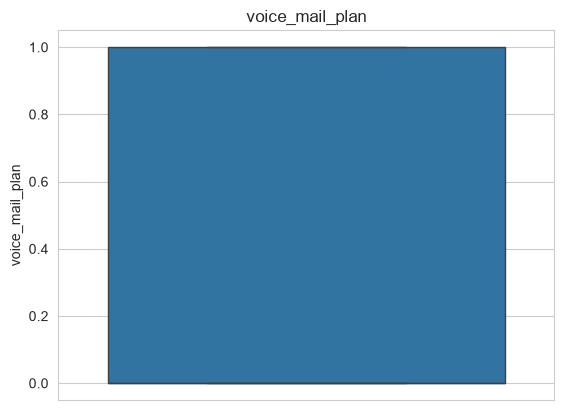

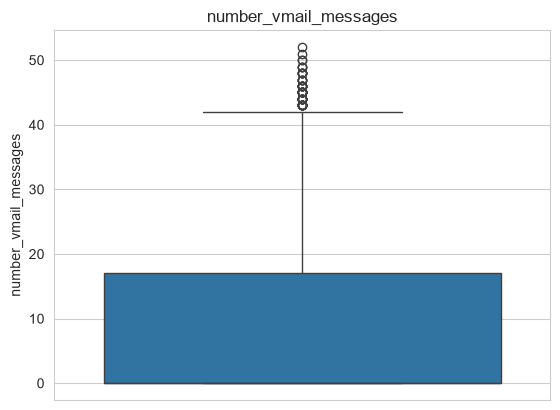

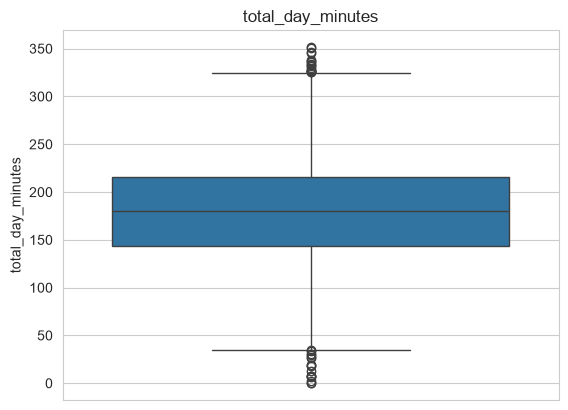

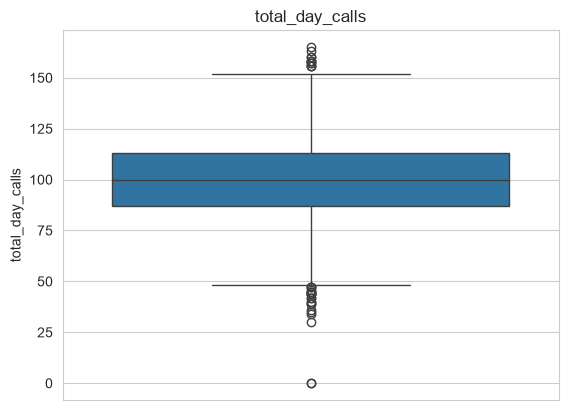

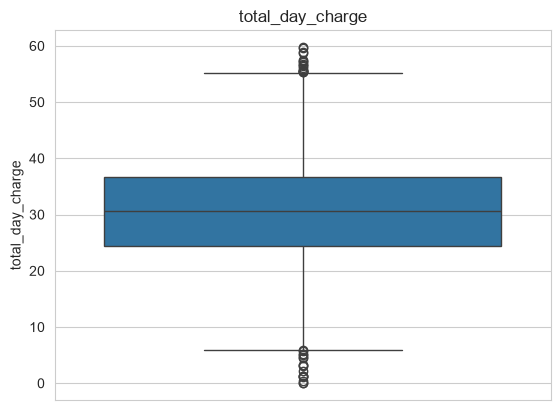

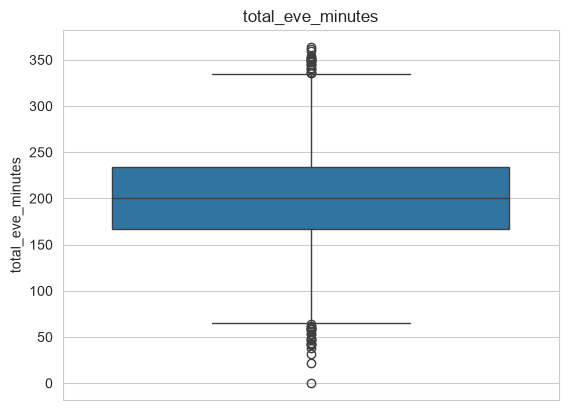

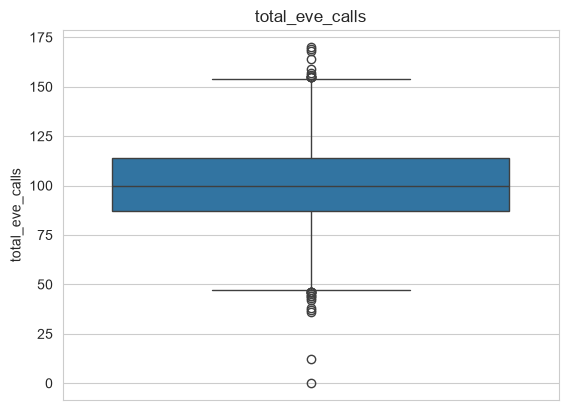

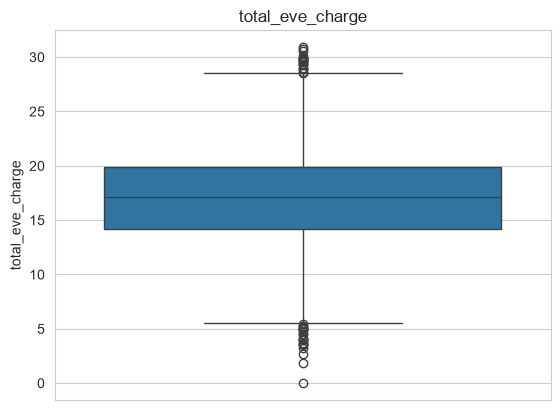

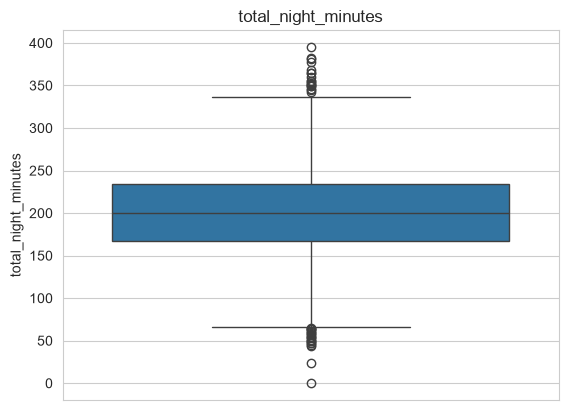

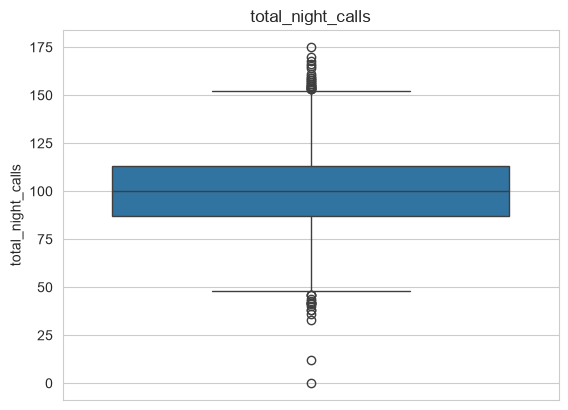

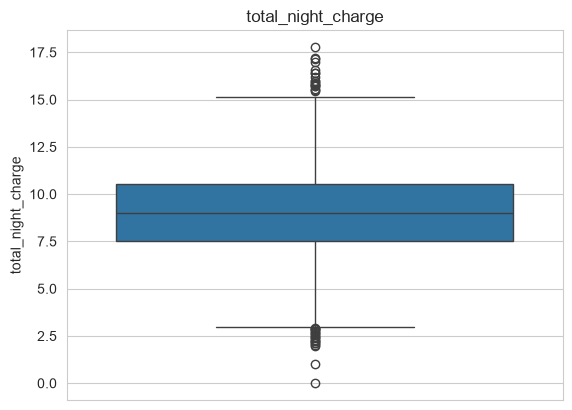

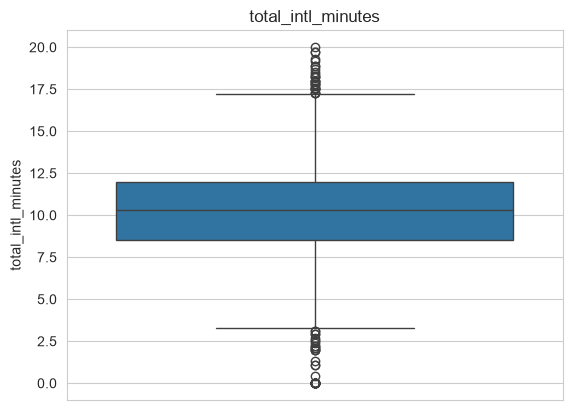

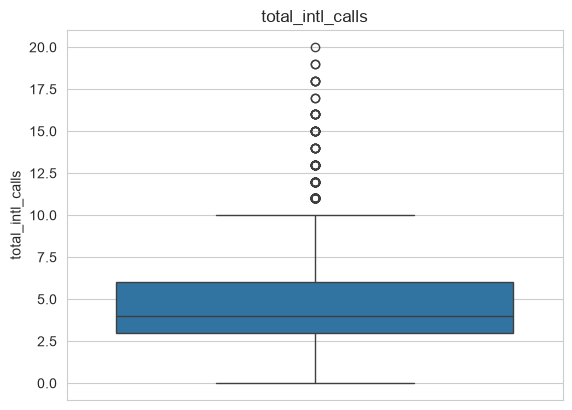

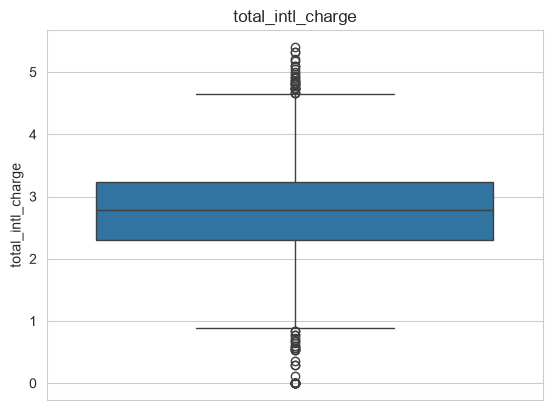

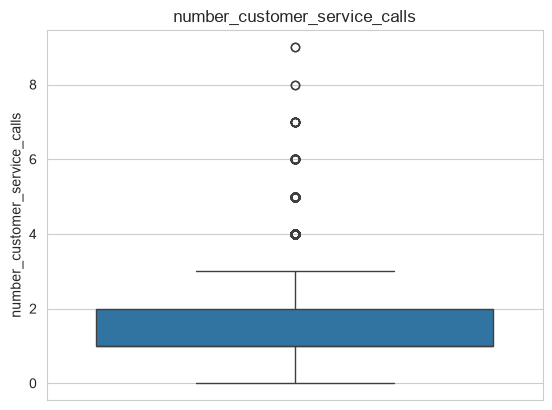

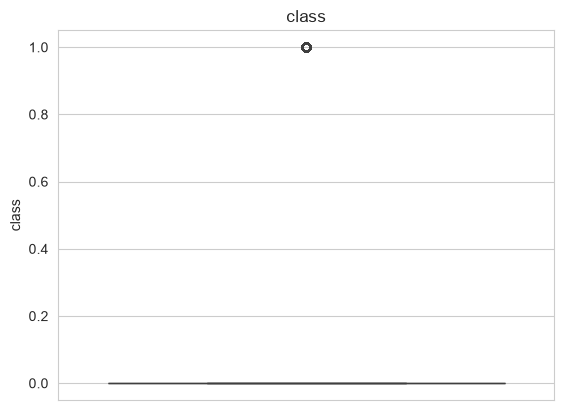

In [11]:
for col in df.columns:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

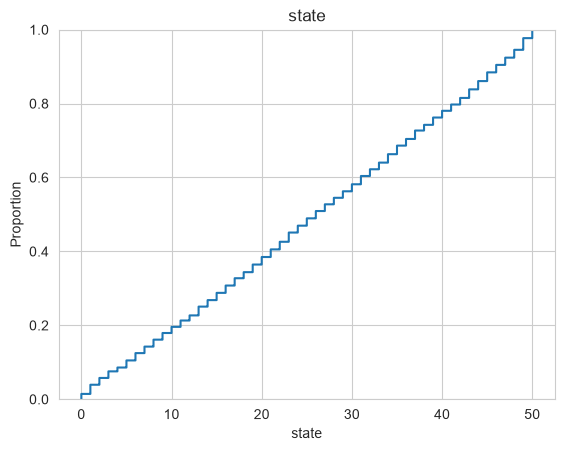

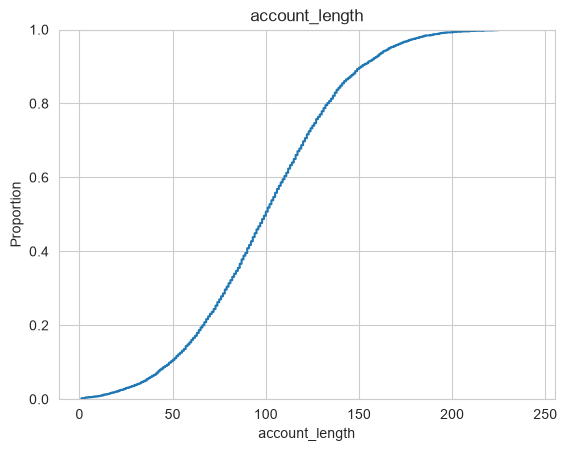

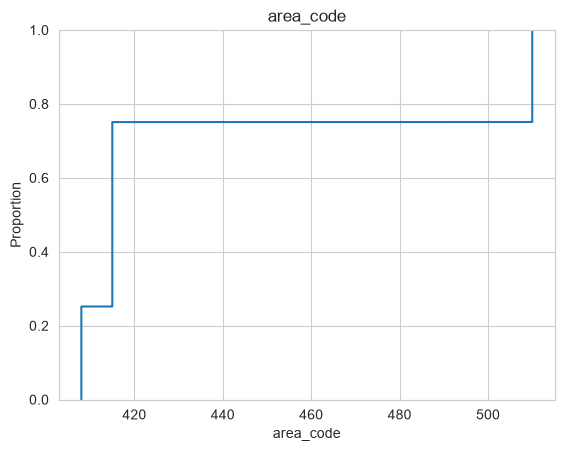

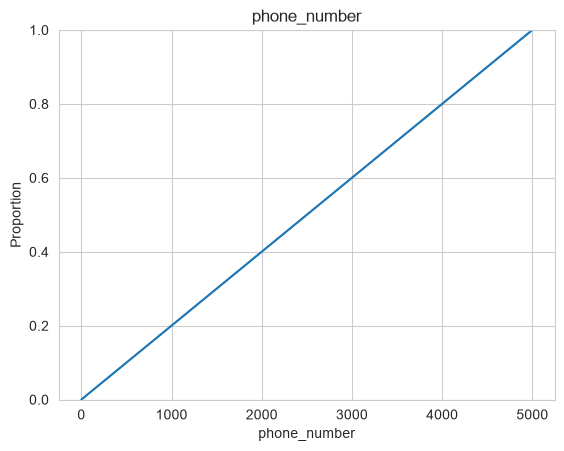

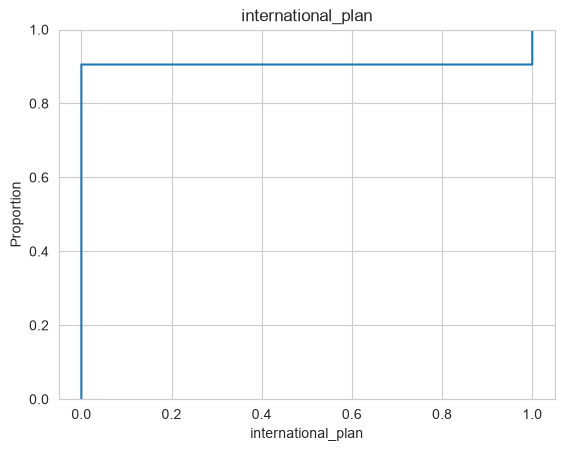

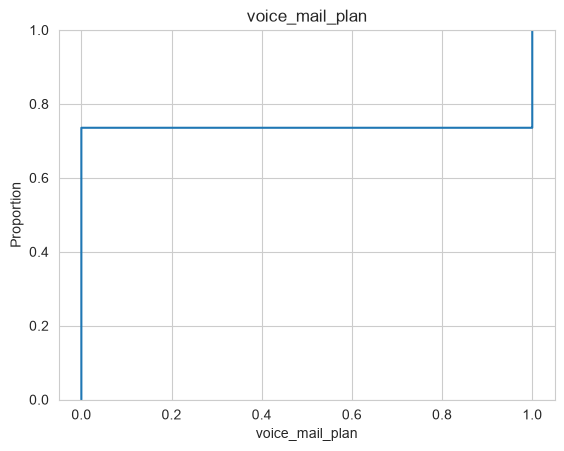

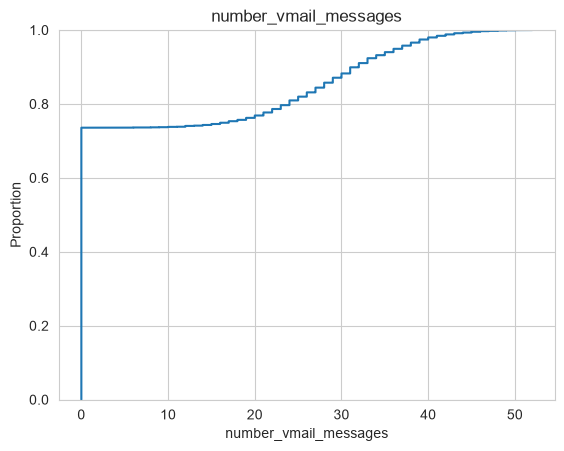

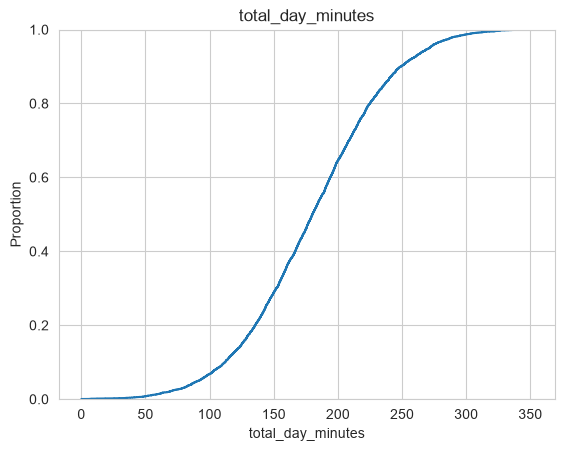

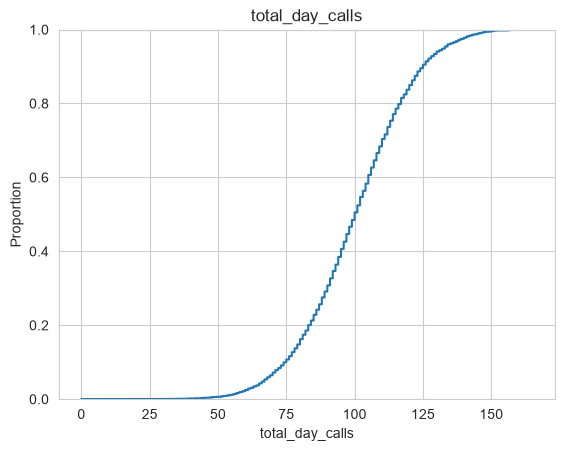

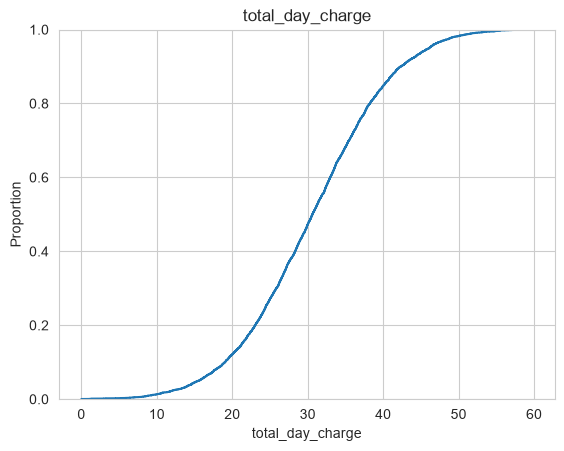

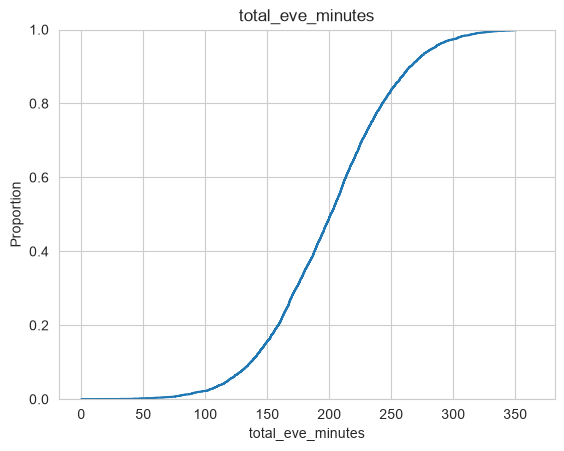

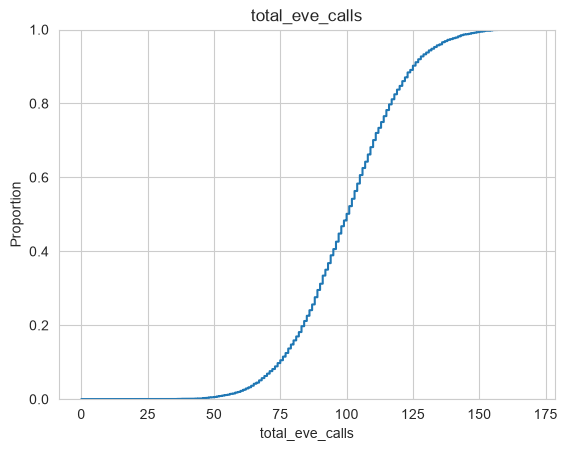

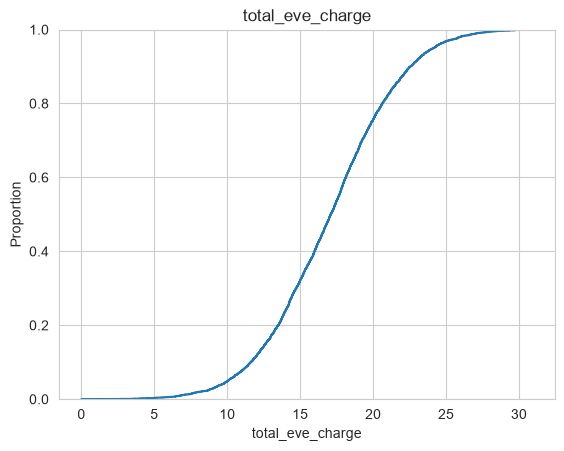

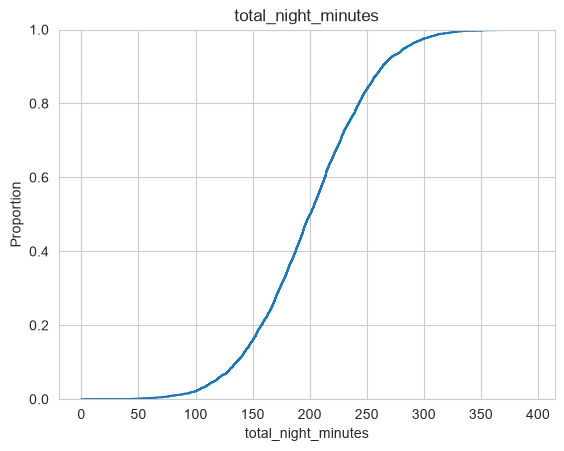

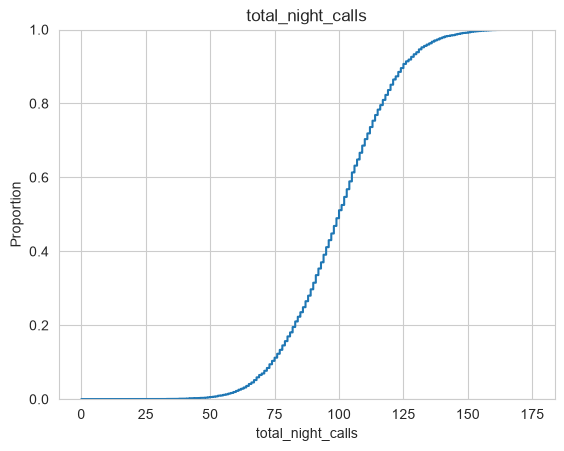

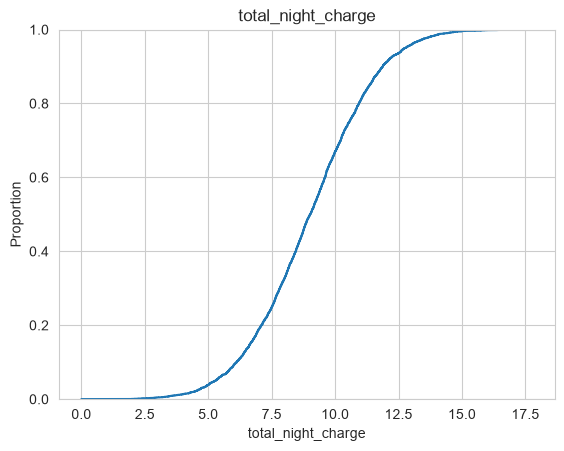

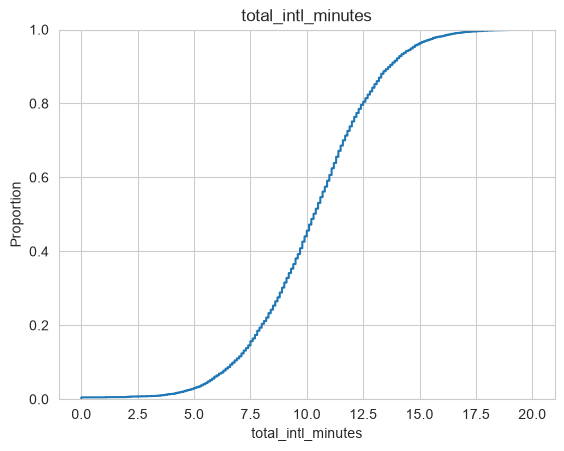

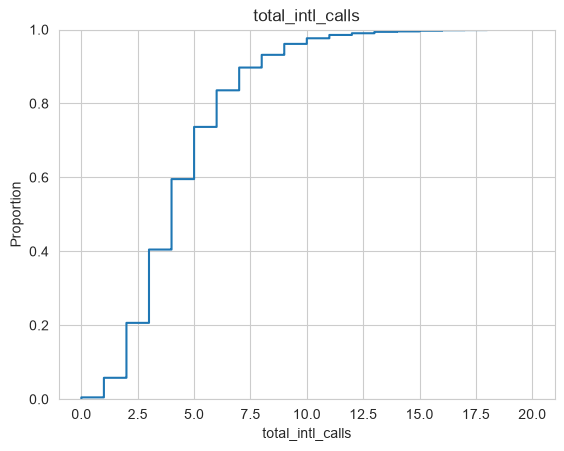

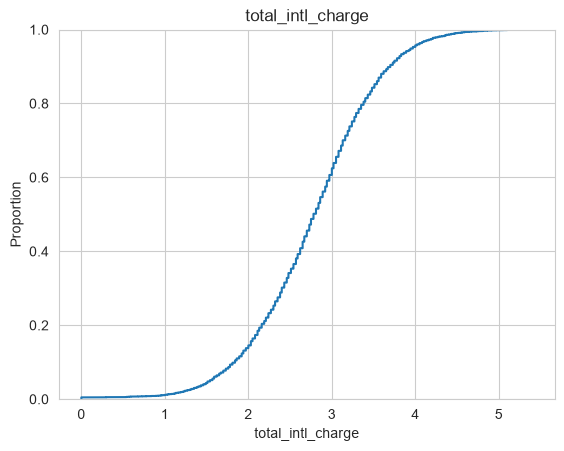

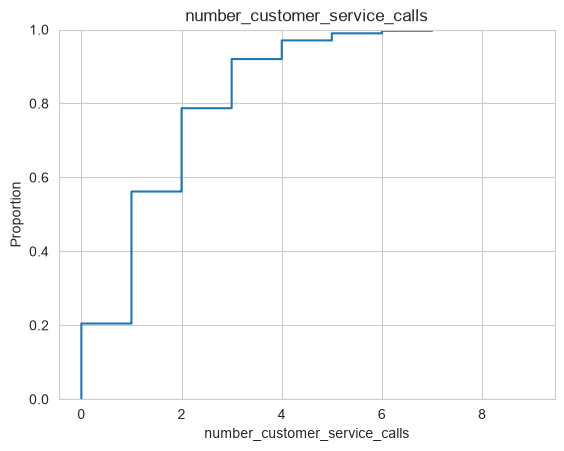

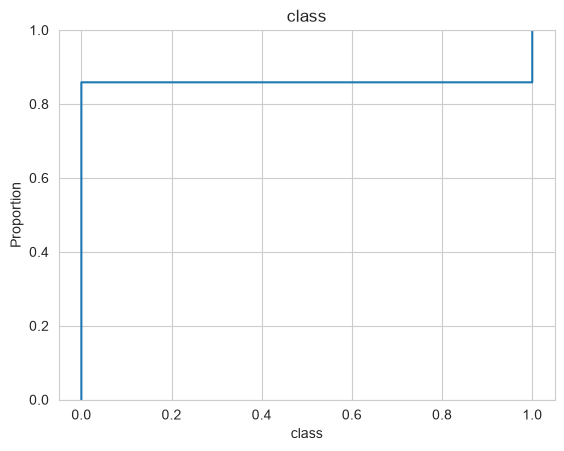

In [12]:
for col in df.columns:
    sns.ecdfplot(df[col])
    plt.title(col)
    plt.show()

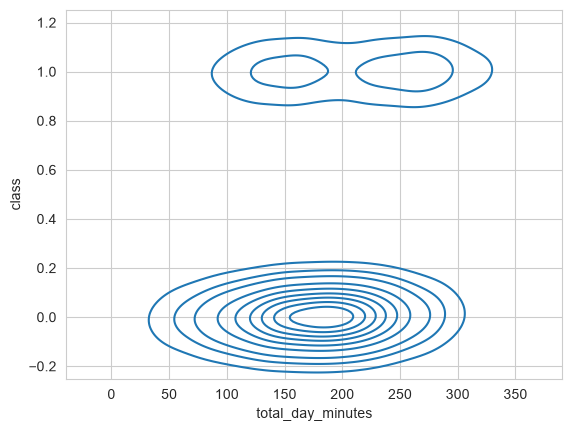

In [13]:
sns.kdeplot(x = 'total_day_minutes', y = 'class', data = df)
plt.show()

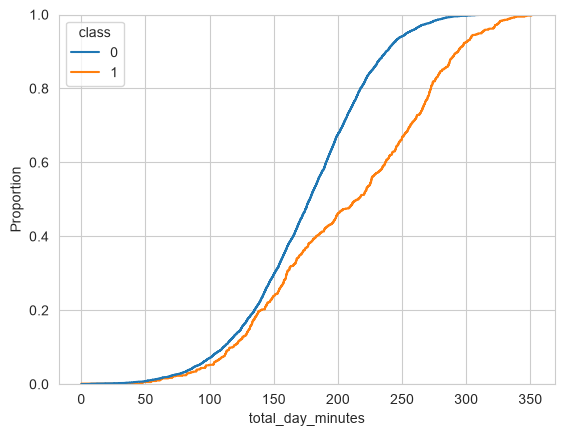

In [14]:
sns.ecdfplot(x='total_day_minutes', hue='class', data=df)
plt.show()

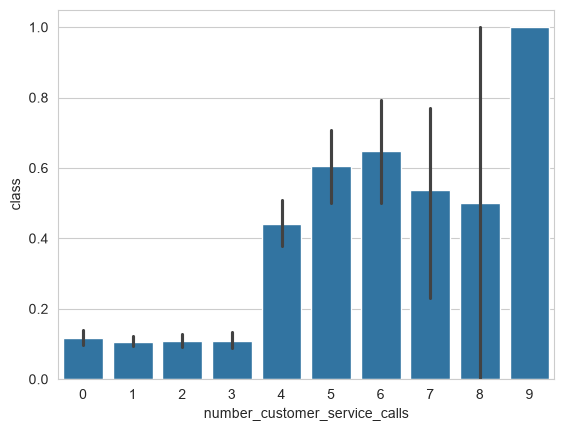

In [15]:
sns.barplot(x = 'number_customer_service_calls', y = 'class', data = df)
plt.show()

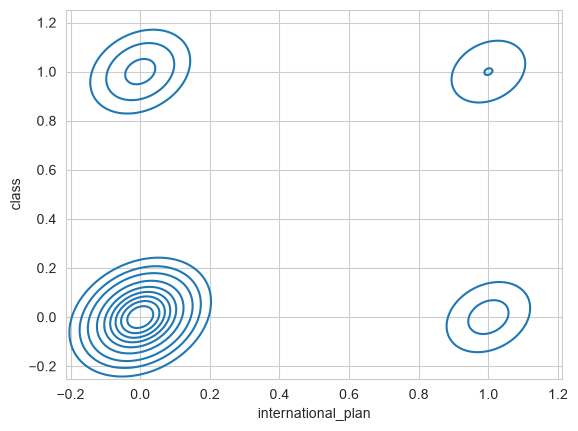

In [16]:
sns.kdeplot(x = 'international_plan', y = 'class', data = df)
plt.show()

In [17]:
pd.crosstab(index = df['international_plan'], columns= df['class'])

class,0,1
international_plan,,
0,4019,508
1,274,199


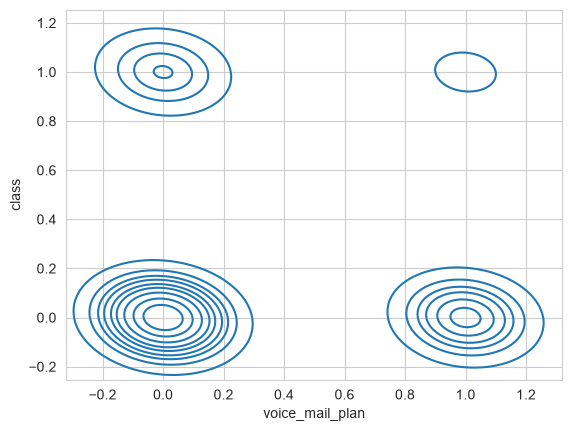

In [18]:
sns.kdeplot(x = 'voice_mail_plan', y = 'class', data = df)
plt.show()

In [19]:
pd.crosstab(index = df['voice_mail_plan'], columns= df['class'])

class,0,1
voice_mail_plan,,
0,3072,605
1,1221,102


In [20]:
pd.crosstab(index = [df['voice_mail_plan'], df['international_plan']], columns= df['class'])

class                                  0    1
voice_mail_plan international_plan           
0               0                   2883  452
                1                    189  153
1               0                   1136   56
                1                     85   46

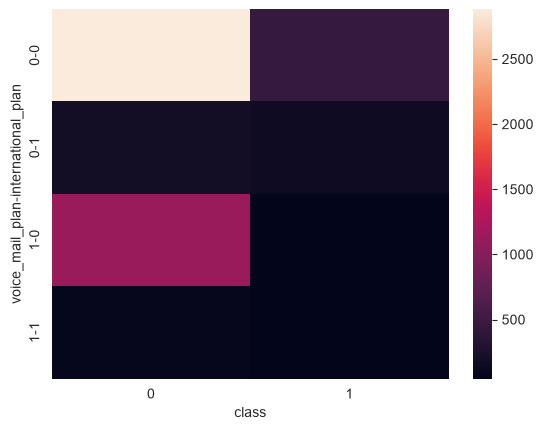

In [21]:
sns.heatmap(pd.crosstab(index = [df['voice_mail_plan'], df['international_plan']], columns= df['class']))
plt.show()

In [22]:
df.columns

Index(['state', 'account_length', 'area_code', 'phone_number',
       'international_plan', 'voice_mail_plan', 'number_vmail_messages',
       'total_day_minutes', 'total_day_calls', 'total_day_charge',
       'total_eve_minutes', 'total_eve_calls', 'total_eve_charge',
       'total_night_minutes', 'total_night_calls', 'total_night_charge',
       'total_intl_minutes', 'total_intl_calls', 'total_intl_charge',
       'number_customer_service_calls', 'class'],
      dtype='str')

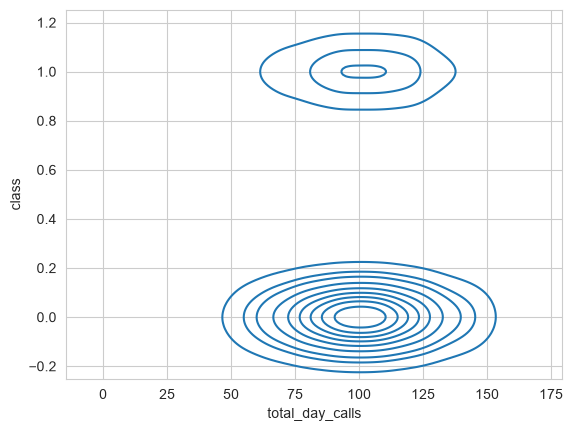

In [23]:
sns.kdeplot(x = 'total_day_calls', y = 'class', data = df)
plt.show()

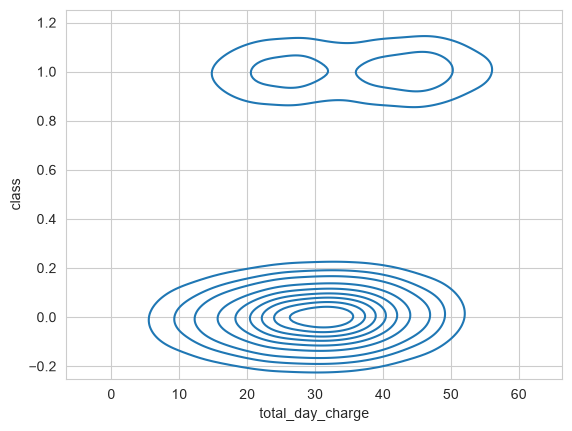

In [24]:
sns.kdeplot(x = 'total_day_charge', y = 'class', data = df)
plt.show()

In [25]:
df['total_bill'] = df['total_day_charge'] + df['total_eve_charge'] + df['total_night_charge'] + df['total_intl_charge']
df['total_minutes'] = df['total_day_minutes'] + df['total_eve_minutes'] + df['total_night_minutes'] + df['total_intl_minutes']
df['day_charge_ratio'] = df['total_day_charge'] / df['total_bill']

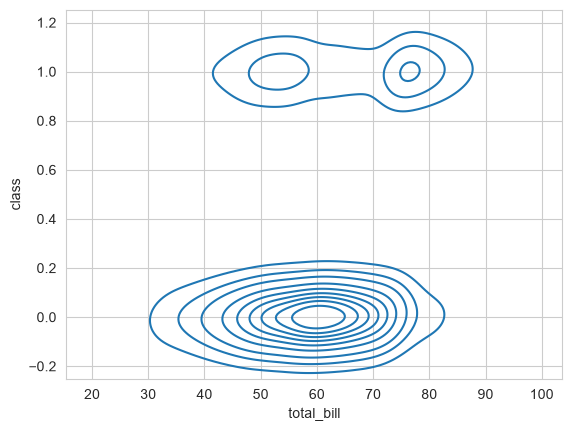

In [26]:
sns.kdeplot(x = 'total_bill', y = 'class',data = df)
plt.show()

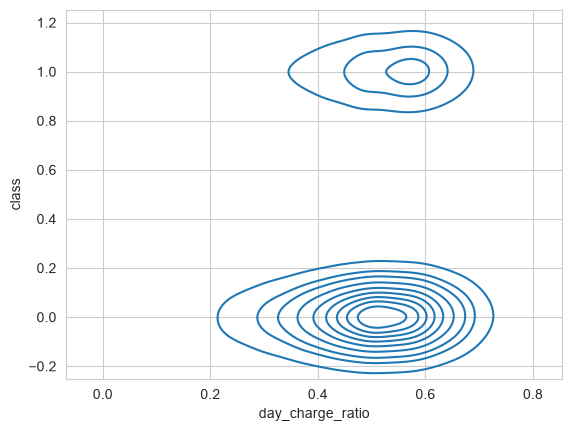

In [27]:
sns.kdeplot(x = 'day_charge_ratio', y = 'class',data = df)
plt.show()

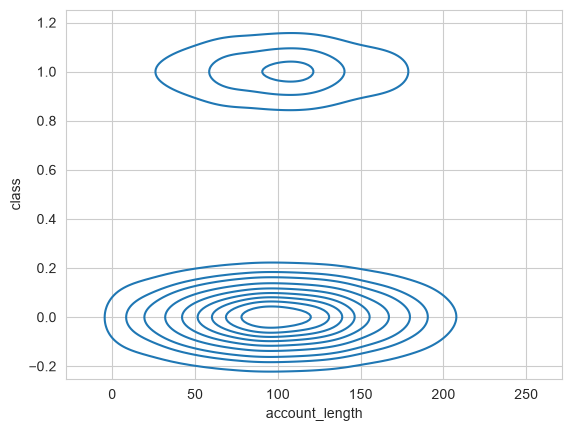

In [28]:
sns.kdeplot(x = 'account_length', y = 'class',data = df)
plt.show()

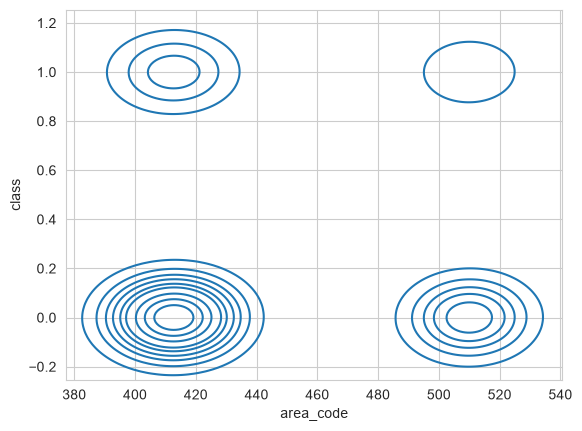

In [29]:
sns.kdeplot(x = 'area_code', y = 'class',data = df)
plt.show()

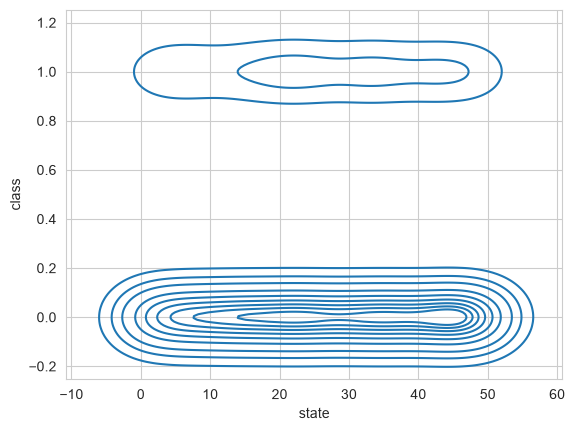

In [30]:
sns.kdeplot(x = 'state', y = 'class',data = df)
plt.show()

In [31]:
df['service_calls_high'] = df['number_customer_service_calls'].apply(lambda x: 1 if x >= 4 else 0)
df['service_calls_high']

0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: service_calls_high, Length: 5000, dtype: int64

In [32]:
df['intl_no_vmail'] = ((df['international_plan'] == 1) & (df['voice_mail_plan'] == 0)).astype(int)
df['intl_no_vmail']

0       0
1       0
2       0
3       1
4       1
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: intl_no_vmail, Length: 5000, dtype: int64

In [33]:
X = df.drop(columns = ['phone_number', 'class', 'state'])
y = df['class']

In [34]:
X.columns

Index(['account_length', 'area_code', 'international_plan', 'voice_mail_plan',
       'number_vmail_messages', 'total_day_minutes', 'total_day_calls',
       'total_day_charge', 'total_eve_minutes', 'total_eve_calls',
       'total_eve_charge', 'total_night_minutes', 'total_night_calls',
       'total_night_charge', 'total_intl_minutes', 'total_intl_calls',
       'total_intl_charge', 'number_customer_service_calls', 'total_bill',
       'total_minutes', 'day_charge_ratio', 'service_calls_high',
       'intl_no_vmail'],
      dtype='str')

In [35]:
cont_col = ['account_length', 'total_day_minutes', 'total_eve_minutes', 'total_night_minutes', 'total_intl_minutes', 'total_bill', 'total_minutes', 'day_charge_ratio']
dis_col = ['total_day_calls', 'total_eve_calls', 'total_night_calls', 'total_intl_calls', 'number_vmail_messages', 'number_customer_service_calls']
cat = ['area_code']
bin_col = ['international_plan', 'voice_mail_plan', 'service_calls_high', 'intl_no_vmail']

In [36]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape

((4000, 23), (1000, 23))

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), cont_col),
        ('scale1', StandardScaler(), dis_col),
        ('ohe', OneHotEncoder(sparse_output=False, drop='first'), cat),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')


In [39]:
X_train = preprocessor.fit_transform(X_train)
X_train

,account_length,total_day_minutes,total_eve_minutes,total_night_minutes,total_intl_minutes,total_bill,total_minutes,day_charge_ratio,total_day_calls,total_eve_calls,total_night_calls,total_intl_calls,number_vmail_messages,number_customer_service_calls,area_code_415,area_code_510,international_plan,voice_mail_plan,total_day_charge,total_eve_charge,total_night_charge,total_intl_charge,service_calls_high,intl_no_vmail
4227,0.470350,-1.992444,-0.793499,0.269189,0.991208,-1.963368,-1.472725,-2.038892,-1.748256,1.607748,-1.663827,0.649260,-0.579557,1.085454,0.0,1.0,0,0,12.53,13.64,9.64,3.51,0,0
4676,2.513979,-1.647016,-0.013860,-1.618260,-1.647027,-1.939079,-1.973388,-1.199598,-0.265708,0.047670,-0.045687,-1.403412,1.555430,-0.444701,1.0,0.0,1,1,15.67,17.00,5.36,1.54,0,0
800,-0.109940,1.510389,0.398657,-0.421486,0.376825,1.437053,0.912187,0.989027,-0.214586,0.047670,-0.146821,-0.992878,1.408189,-0.444701,1.0,0.0,0,1,44.42,18.78,8.07,3.05,0,0
3671,1.025410,-0.788112,-0.479670,-0.352022,0.304544,-0.953929,-0.940490,-0.369051,-0.316831,-0.807856,0.510548,0.649260,-0.579557,1.085454,0.0,1.0,0,0,23.49,14.99,8.23,3.00,0,0
4193,0.899260,-0.896409,1.053949,-0.479042,0.991208,-0.385573,-0.180475,-1.100405,0.501127,-0.958831,0.004880,0.649260,-0.579557,0.320376,0.0,1.0,0,0,22.51,21.60,7.94,3.51,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,-0.210860,1.116414,-1.837623,-0.873997,-0.996503,-0.045531,-0.903278,2.005269,-0.725810,-1.059481,1.066784,-0.171809,-0.579557,-0.444701,0.0,1.0,0,0,40.83,9.15,7.05,2.03,0,0
466,0.798340,0.855008,-0.377034,1.154365,0.087703,0.859953,0.959547,0.605008,0.143270,1.255472,0.106013,0.238726,2.070772,1.085454,0.0,1.0,0,1,38.45,15.44,11.65,2.84,0,0
3092,-0.816379,-1.611539,-1.048115,0.255296,-0.056858,-1.810835,-1.428748,-1.250748,-0.367953,-1.009156,-0.753623,-0.992878,-0.579557,-1.209779,1.0,0.0,0,0,16.00,12.55,9.61,2.73,0,0
3772,-0.034250,0.240705,0.777621,-1.090330,0.702087,0.348918,-0.007949,0.152443,-2.515092,0.852872,-0.399655,-0.171809,-0.579557,-0.444701,0.0,0.0,0,0,32.86,20.41,6.56,3.29,0,0


In [40]:
X_test = preprocessor.transform(X_test)
X_test

,account_length,total_day_minutes,total_eve_minutes,total_night_minutes,total_intl_minutes,total_bill,total_minutes,day_charge_ratio,total_day_calls,total_eve_calls,total_night_calls,total_intl_calls,number_vmail_messages,number_customer_service_calls,area_code_415,area_code_510,international_plan,voice_mail_plan,total_day_charge,total_eve_charge,total_night_charge,total_intl_charge,service_calls_high,intl_no_vmail
1501,-0.715459,1.717647,-1.831702,-0.300419,0.882788,0.751139,-0.152284,1.974788,-0.623565,1.255472,-0.955891,-0.992878,-0.579557,-1.209779,0.0,1.0,0,0,46.31,9.17,8.35,3.43,0,0
2586,-1.194829,-0.304512,0.104566,-0.117827,0.412965,-0.221381,-0.178220,-0.208490,0.296637,-2.216958,1.218484,-0.992878,-0.579557,-0.444701,1.0,0.0,0,0,27.90,17.51,8.76,3.08,0,0
2653,1.378630,-2.218374,1.073687,0.501399,0.774367,-1.346434,-0.417275,-3.009217,0.143270,0.500596,-0.197388,0.238726,1.629050,-0.444701,0.0,0.0,0,1,10.47,21.68,10.17,3.35,0,0
1055,1.530010,-0.043106,-1.069827,-1.251090,-0.635101,-0.807225,-1.367857,0.918376,0.450004,-0.707206,-1.107591,-0.992878,-0.579557,-0.444701,1.0,0.0,0,0,30.28,12.45,6.19,2.30,0,0
705,-0.034250,-2.194100,0.598008,-0.629879,-0.635101,-1.874957,-1.361091,-2.613456,-0.981421,-1.814358,1.066784,0.238726,-0.579557,-0.444701,1.0,0.0,0,0,10.69,19.64,7.60,2.30,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4711,-1.876039,0.261244,0.742093,0.763379,-0.237559,0.692846,1.008035,-0.116645,0.245515,-0.002655,1.471319,0.238726,-0.579557,-1.209779,1.0,0.0,1,0,33.05,20.26,10.76,2.59,0,1
2313,1.504780,1.411429,-0.262555,-1.618260,0.449105,0.815262,-0.203027,1.456404,0.552249,-1.965333,-0.955891,-0.171809,-0.579557,1.085454,1.0,0.0,0,0,43.52,15.93,5.36,3.11,0,0
3214,1.227250,0.009175,-0.114523,-0.056301,-0.526680,-0.090222,-0.108307,0.197461,-1.083666,-0.858181,0.459981,1.880864,-0.579557,1.085454,0.0,1.0,1,0,30.75,16.57,8.90,2.38,0,1
2732,0.747880,0.668290,3.217200,-1.467422,2.400676,1.786810,1.482762,-0.378852,0.296637,-0.707206,1.167917,-0.992878,-0.579557,2.615609,0.0,0.0,1,0,36.75,30.91,5.70,4.56,1,1


## Logistic Regression

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state= 42)
res = cross_val_score(estimator= LogisticRegression(class_weight='balanced', max_iter=1000), cv = cv, X = X_train, y = y_train, scoring = 'f1')
res1 = cross_val_score(estimator= LogisticRegression(class_weight='balanced', max_iter=1000), cv = cv, X = X_train, y = y_train, scoring = 'roc_auc')


In [42]:
res.mean(), res1.mean()

(np.float64(0.620265896582561), np.float64(0.8718580099229559))

## Ridge

In [43]:
from sklearn.linear_model import RidgeClassifier

cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state= 42)
res = cross_val_score(estimator= RidgeClassifier(class_weight='balanced', random_state=42), cv = cv, X = X_train, y = y_train, scoring = 'f1')
res1 = cross_val_score(estimator= RidgeClassifier(class_weight='balanced', random_state=42), cv = cv, X = X_train, y = y_train, scoring = 'roc_auc')

In [44]:
res.mean(), res1.mean()

(np.float64(0.6285142878861404), np.float64(0.8724685809634944))

## Lasso

In [45]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state= 42)
res = cross_val_score(estimator= LogisticRegression(penalty = 'l1', solver='liblinear',class_weight='balanced', max_iter=2000), cv = cv, X = X_train, y = y_train, scoring = 'f1')
res1 = cross_val_score(estimator= LogisticRegression(penalty = 'l1', solver='liblinear',class_weight='balanced', max_iter=2000), cv = cv, X = X_train, y = y_train, scoring = 'roc_auc')


c:\AEGIS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\AEGIS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\AEGIS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ra

In [46]:
res.mean(), res1.mean()

(np.float64(0.6206964350276472), np.float64(0.8719365913263013))

## DecisionTree

In [47]:
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state= 42)
res = cross_val_score(estimator= DecisionTreeClassifier(class_weight='balanced', random_state=42), cv = cv, X = X_train, y = y_train, scoring = 'f1')
res1 = cross_val_score(estimator= DecisionTreeClassifier(class_weight='balanced', random_state=42), cv = cv, X = X_train, y = y_train, scoring = 'roc_auc')

res.mean(), res1.mean()

(np.float64(0.8450684055747347), np.float64(0.9110251251624198))

## RandomForestClassifier

In [48]:
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state= 42)
res = cross_val_score(estimator= RandomForestClassifier(n_estimators= 200, n_jobs=-1,class_weight='balanced', random_state=42), cv = cv, X = X_train, y = y_train, scoring = 'f1')
res1 = cross_val_score(estimator= RandomForestClassifier(n_estimators= 200, n_jobs=-1,class_weight='balanced', random_state=42), cv = cv, X = X_train, y = y_train, scoring = 'roc_auc')

res.mean(), res1.mean()

(np.float64(0.9022526887793625), np.float64(0.9209157001827085))

## BaggingClassifier

In [49]:
from sklearn.ensemble import BaggingClassifier

?BaggingClassifier

Init signature:
BaggingClassifier(
    estimator=None,
    n_estimators=10,
    *,
    max_samples=None,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    oob_score=False,
    warm_start=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
)
Docstring:     
A Bagging classifier.

A Bagging classifier is an ensemble meta-estimator that fits base
classifiers each on random subsets of the original dataset and then
aggregate their individual predictions (either by voting or by averaging)
to form a final prediction. Such a meta-estimator can typically be used as
a way to reduce the variance of a black-box estimator (e.g., a decision
tree), by introducing randomization into its construction procedure and
then making an ensemble out of it.

This algorithm encompasses several works from the literature. When random
subsets of the dataset are drawn as random subsets of the samples, then
this algorithm is known as Pasting [1]_. If samples are drawn with
replacem

In [50]:
cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state= 42)
res = cross_val_score(estimator= BaggingClassifier(n_estimators= 200, n_jobs=-1, random_state=42, oob_score=True), cv = cv, X = X_train, y = y_train, scoring = 'f1')
res1 = cross_val_score(estimator= BaggingClassifier(n_estimators= 200, n_jobs=-1, random_state=42, oob_score=True), cv = cv, X = X_train, y = y_train, scoring = 'roc_auc')

res.mean(), res1.mean()

(np.float64(0.9060350259120085), np.float64(0.9214037607479157))

## HistGradientBoosting

In [51]:
from sklearn.ensemble import HistGradientBoostingClassifier

cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state= 42)
res = cross_val_score(estimator= HistGradientBoostingClassifier(class_weight='balanced', random_state=42), cv = cv, X = X_train, y = y_train, scoring = 'f1')
res1 = cross_val_score(estimator= HistGradientBoostingClassifier(class_weight='balanced', random_state=42), cv = cv, X = X_train, y = y_train, scoring = 'roc_auc')

res.mean(), res1.mean()

(np.float64(0.921325484781484), np.float64(0.9240525658948089))

## XGBoost

In [52]:
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state= 42)
res = cross_val_score(estimator= XGBClassifier(scale_pos_weight=6.07, eval_metric='logloss', random_state=42, device = 'cuda'), cv = cv, X = X_train, y = y_train, scoring = 'f1')
res1 = cross_val_score(estimator= XGBClassifier(scale_pos_weight=6.07, eval_metric='logloss', random_state=42, device = 'cuda'), cv = cv, X = X_train, y = y_train, scoring = 'roc_auc')

res.mean(), res1.mean()

c:\AEGIS\.venv\Lib\site-packages\xgboost\core.py:569: UserWarning: [20:56:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


(np.float64(0.914472099361521), np.float64(0.9254352892569973))

## CatBoost

In [53]:
from catboost import CatBoostClassifier

?CatBoostClassifier

Init signature:
CatBoostClassifier(
    iterations=None,
    learning_rate=None,
    depth=None,
    l2_leaf_reg=None,
    model_size_reg=None,
    rsm=None,
    loss_function=None,
    border_count=None,
    feature_border_type=None,
    per_float_feature_quantization=None,
    input_borders=None,
    output_borders=None,
    fold_permutation_block=None,
    od_pval=None,
    od_wait=None,
    od_type=None,
    nan_mode=None,
    counter_calc_method=None,
    leaf_estimation_iterations=None,
    leaf_estimation_method=None,
    thread_count=None,
    random_seed=None,
    use_best_model=None,
    best_model_min_trees=None,
    verbose=None,
    silent=None,
    logging_level=None,
    metric_period=None,
    ctr_leaf_count_limit=None,
    store_all_simple_ctr=None,
    max_ctr_complexity=None,
    has_time=None,
    allow_const_label=None,
    target_border=None,
    classes_count=None,
    class_weights=None,
    auto_class_weights=None,
    class_names=None,
    one_hot_max_size=Non

In [65]:
cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state= 42)
res = cross_val_score(estimator= CatBoostClassifier(), cv = cv, X = X_train, y = y_train, scoring = 'f1')
res1 = cross_val_score(estimator= CatBoostClassifier(), cv = cv, X = X_train, y = y_train, scoring = 'roc_auc')

res.mean(), res1.mean()

Learning rate set to 0.016929
0:	learn: 0.6718984	total: 164ms	remaining: 2m 43s
1:	learn: 0.6501633	total: 170ms	remaining: 1m 25s
2:	learn: 0.6315245	total: 178ms	remaining: 59s
3:	learn: 0.6142400	total: 184ms	remaining: 45.8s
4:	learn: 0.5900518	total: 192ms	remaining: 38.3s
5:	learn: 0.5721863	total: 195ms	remaining: 32.3s
6:	learn: 0.5542996	total: 198ms	remaining: 28.2s
7:	learn: 0.5360985	total: 201ms	remaining: 24.9s
8:	learn: 0.5183876	total: 205ms	remaining: 22.6s
9:	learn: 0.5060715	total: 208ms	remaining: 20.6s
10:	learn: 0.4930124	total: 211ms	remaining: 19s
11:	learn: 0.4796578	total: 215ms	remaining: 17.7s
12:	learn: 0.4670004	total: 221ms	remaining: 16.8s
13:	learn: 0.4518787	total: 225ms	remaining: 15.9s
14:	learn: 0.4365251	total: 230ms	remaining: 15.1s
15:	learn: 0.4225076	total: 233ms	remaining: 14.3s
16:	learn: 0.4103341	total: 236ms	remaining: 13.7s
17:	learn: 0.4010986	total: 239ms	remaining: 13s
18:	learn: 0.3921331	total: 242ms	remaining: 12.5s
19:	learn: 0.38

(np.float64(0.9201553271975806), np.float64(0.9229179626811744))

## LightGBM

In [55]:
from lightgbm import LGBMClassifier

cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state= 42)
res = cross_val_score(estimator= LGBMClassifier(), cv = cv, X = X_train, y = y_train, scoring = 'f1')
res1 = cross_val_score(estimator= LGBMClassifier(), cv = cv, X = X_train, y = y_train, scoring = 'roc_auc')

res.mean(), res1.mean()

[LightGBM] [Info] Number of positive: 455, number of negative: 2745
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3188
[LightGBM] [Info] Number of data points in the train set: 3200, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.142187 -> initscore=-1.797239
[LightGBM] [Info] Start training from score -1.797239
[LightGBM] [Info] Number of positive: 455, number of negative: 2745
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3179
[LightGBM] [Info] Number of data points in the train set: 3200, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.142187 -> initscore=-1.797239
[LightGBM] [Info] Start training from score -1.797239
[LightGBM] [Info] Nu

(np.float64(0.9159750302839378), np.float64(0.9272456292884504))

# HyperParameter Tuning

## HistGradientBoosting

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'learning_rate' : [0.03, 0.05, 0.08, 0.1],
    'max_leaf_nodes' : [15, 31, 63],
    'min_samples_leaf' : [10, 20, 30],
    'l2_regularization' : [0.0, 0.1, 1.0, 5.0],
    'class_weight' : ['balanced', None],
} 

grid = GridSearchCV(
    estimator = HistGradientBoostingClassifier(random_state=4),
    param_grid=param_grid,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring = 'f1',
    n_jobs= -1
)

In [61]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...andom_state=4)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'l2_regularization': [0.0, 0.1, ...], 'learning_rate': [0.03, 0.05, ...], 'max_leaf_nodes': [15, 31, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versioncha

In [62]:
grid.best_params_

{'class_weight': 'balanced',
 'l2_regularization': 0.1,
 'learning_rate': 0.1,
 'max_leaf_nodes': 63,
 'min_samples_leaf': 20}

In [63]:
grid.best_score_

np.float64(0.9230654115214108)

In [64]:
from sklearn.metrics import f1_score, roc_auc_score

print(f1_score(y_test, grid.best_estimator_.predict(X_test)), end = " ")
print(roc_auc_score(y_test, grid.best_estimator_.predict(X_test)))

0.9348659003831418 0.9388489208633093


## XGBoost

In [59]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.08, 0.1, 0.15],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1.0, 2.5, 4.0, 6.07],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0, 10.0]
}

xgb_model = XGBClassifier(
    device='cuda',
    tree_method='hist',
    eval_metric='logloss',
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=1 
)

xgb_search.fit(X_train, y_train)

print(f"XGBoost Best 5-Fold CV F1: {xgb_search.best_score_:.4f}")
print("XGBoost Best Parameters:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")


XGBoost Best 5-Fold CV F1: 0.9231
XGBoost Best Parameters:
  subsample: 1.0
  scale_pos_weight: 1.0
  reg_lambda: 10.0
  reg_alpha: 0.5
  n_estimators: 200
  max_depth: 3
  learning_rate: 0.1
  colsample_bytree: 0.7


In [60]:
from sklearn.metrics import f1_score, roc_auc_score

print(f1_score(y_test, xgb_search.best_estimator_.predict(X_test)), end = " ")
print(roc_auc_score(y_test, xgb_search.best_estimator_.predict(X_test)))

0.9348659003831418 0.9388489208633093
